# Chapter 13: Time Series Clustering

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Cluster **ECG (electrocardiogram)** time series from the **UCR (University of California, Riverside) Time Series Archive** using **k-Shape**, **k-Means (Euclidean)**, and **HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)**.

---

## What you will learn

1. Why standard Euclidean distance fails for misaligned time series
2. Load **ECGFiveDays** and **ECG5000** via **tslearn (Time Series Learn)**
3. **k-Shape** clustering with shape-based distance (SBD — Shape-Based Distance)
4. **TimeSeriesKMeans** with Euclidean distance
5. **HDBSCAN** on flattened series for density-based clusters
6. Compare algorithms with **centroid plots**, sample series, and a summary table


## Setup — run this cell first

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Arrays and math |
| **Pandas (Python Data Analysis Library)** | Comparison tables |
| **Matplotlib (Mathematical Plotting Library)** | Time series and centroid plots |
| **tslearn (Time Series Learn)** | UCR datasets, k-Shape, TimeSeriesKMeans |
| **hdbscan** | HDBSCAN density clustering |
| **scikit-learn (Scientific Kit for Learning)** | Adjusted Rand Index (ARI) evaluation |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide clustering library warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for comparison tables
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for time series plots
import matplotlib.pyplot as plt

# Import tslearn (Time Series Learn) UCR dataset loader
from tslearn.datasets import UCR_UEA_datasets

# Import k-Shape and Euclidean time-series k-Means from tslearn
from tslearn.clustering import KShape, TimeSeriesKMeans

# Import tslearn preprocessing to ensure consistent series shape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

# Import HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)
import hdbscan

# Import Adjusted Rand Index to compare clusters with true ECG class labels
from sklearn.metrics import adjusted_rand_score

# Import display() for rich table output inside Jupyter
from IPython.display import display

# Confirm setup completed without errors
print("Libraries loaded successfully.")


Libraries loaded successfully.


---

## Libraries Imported in This Notebook

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **NumPy (Numerical Python)** (`np`) | Array operations | Store ECG series |
| **Pandas (Python Data Analysis Library)** (`pd`) | DataFrames | Algorithm comparison table |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Line plots | Centroids and sample series |
| **tslearn.datasets.UCR_UEA_datasets** | Download UCR archive datasets | Load ECGFiveDays and ECG5000 |
| **tslearn.clustering.KShape** | Shape-based k-Means variant | Chapter 13 primary algorithm |
| **tslearn.clustering.TimeSeriesKMeans** | k-Means for time series | Euclidean baseline comparison |
| **hdbscan.HDBSCAN** | Density clustering | Find clusters without fixing k |
| **sklearn.metrics.adjusted_rand_score** | Cluster vs label agreement | Evaluation when true labels exist |


---

## Algorithms Used in This Notebook

### 1. k-Shape (`KShape`)
- **Type:** Centroid-based clustering for time series
- **Distance:** **SBD (Shape-Based Distance)** — invariant to scaling and shifting
- **Centroids:** Shape averages (not simple arithmetic means)
- **Best for:** ECG morphologies with similar shape but phase shift

### 2. TimeSeriesKMeans (Euclidean)
- **Type:** k-Means with Euclidean distance on aligned series
- **Finds:** k groups minimizing sum of squared point-to-centroid distances
- **Weakness:** Sensitive to horizontal (time) misalignment

### 3. HDBSCAN (`hdbscan.HDBSCAN`)
- **Type:** Hierarchical density-based clustering
- **Finds:** Clusters of varying density; marks outliers as noise (-1)
- **Our demo:** Flatten each series to 1-D vector (teaching simplification)

### Evaluation note (important for beginners)

Clustering is **unsupervised**. We use ECG class labels **only** to compute **ARI (Adjusted Rand Index)** for teaching comparison — not available in real deployment.


---

## 1. Approach to Time Series Clustering

Time series are ordered sequences — **Euclidean distance** treats time index 1 vs 100 as fixed, so two identical heartbeats shifted in time look very different.

| Method | Handles misalignment? | Must specify k? |
|--------|----------------------|-----------------|
| **k-Shape** | Yes (shape-based) | Yes |
| **Euclidean k-Means** | No | Yes |
| **HDBSCAN** | No (on flattened series) | No |


---

## 2. Load ECG (Electrocardiogram) Data from UCR Archive

**ECGFiveDays** — 2 classes, short series (136 time steps).  
**ECG5000** — 5 classes, 140 time steps (we use a subset for speed).


In [2]:
# Load ECGFiveDays from UCR (University of California, Riverside) archive via tslearn
X_tr_five, y_tr_five, X_te_five, y_te_five = UCR_UEA_datasets().load_dataset("ECGFiveDays")

# Combine train and test for clustering demo (book evaluates on full dataset)
X_five = np.vstack([X_tr_five, X_te_five])

y_five = np.concatenate([y_tr_five, y_te_five]).ravel()

# Load ECG5000 (larger dataset — use subset for classroom runtime)
X_tr_ecg, y_tr_ecg, X_te_ecg, y_te_ecg = UCR_UEA_datasets().load_dataset("ECG5000")

X_ecg = np.vstack([X_tr_ecg, X_te_ecg])

y_ecg = np.concatenate([y_tr_ecg, y_te_ecg]).ravel()

# Subsample ECG5000 for faster clustering (800 series)
rng = np.random.default_rng(42)

sub_idx = rng.choice(len(X_ecg), size=min(800, len(X_ecg)), replace=False)

X_ecg_sub = X_ecg[sub_idx]

y_ecg_sub = y_ecg[sub_idx]

# Scale each series to zero mean and unit variance (tslearn best practice)
scaler = TimeSeriesScalerMeanVariance()

X_five_scaled = scaler.fit_transform(X_five)

X_ecg_scaled = scaler.fit_transform(X_ecg_sub)

print(f"ECGFiveDays: {X_five_scaled.shape}, classes: {len(np.unique(y_five))}")
print(f"ECG5000 subset: {X_ecg_scaled.shape}, classes: {len(np.unique(y_ecg_sub))}")


ECGFiveDays: (884, 136, 1), classes: 2
ECG5000 subset: (800, 140, 1), classes: 5


---

## 3. k-Shape on ECGFiveDays

Primary algorithm from Chapter 13 — cluster count k = number of true classes (2).


k-Shape ECGFiveDays — ARI: 0.7944


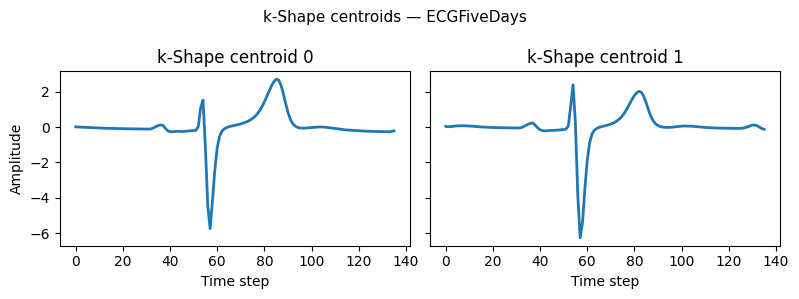

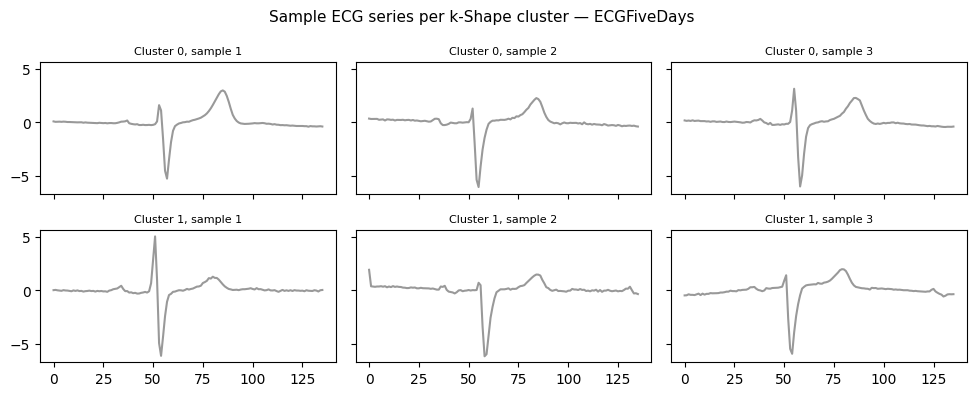

In [3]:
# Number of clusters matches known ECG classes for teaching evaluation
N_CLUSTERS_FIVE = 2

# Fit k-Shape on ECGFiveDays
kshape_five = KShape(n_clusters=N_CLUSTERS_FIVE, random_state=42, n_init=3)

labels_kshape_five = kshape_five.fit_predict(X_five_scaled)

# Adjusted Rand Index (ARI) — 1.0 = perfect match with true labels, 0 ≈ random
ari_kshape_five = adjusted_rand_score(y_five, labels_kshape_five)

print(f"k-Shape ECGFiveDays — ARI: {ari_kshape_five:.4f}")

# Plot k-Shape centroids (learned cluster representatives)
fig, axes = plt.subplots(1, N_CLUSTERS_FIVE, figsize=(8, 3), sharey=True)

for c in range(N_CLUSTERS_FIVE):

    axes[c].plot(kshape_five.cluster_centers_[c].ravel(), color="C0", linewidth=2)

    axes[c].set_title(f"k-Shape centroid {c}")

    axes[c].set_xlabel("Time step")

axes[0].set_ylabel("Amplitude")

plt.suptitle("k-Shape centroids — ECGFiveDays", fontsize=11)

plt.tight_layout()

plt.show()

# Plot sample series from each cluster
fig, axes = plt.subplots(N_CLUSTERS_FIVE, 3, figsize=(10, 4), sharex=True, sharey=True)

for c in range(N_CLUSTERS_FIVE):

    members = np.where(labels_kshape_five == c)[0][:3]

    for j, idx in enumerate(members):

        axes[c, j].plot(X_five_scaled[idx].ravel(), color="gray", alpha=0.8)

        axes[c, j].set_title(f"Cluster {c}, sample {j+1}", fontsize=8)

plt.suptitle("Sample ECG series per k-Shape cluster — ECGFiveDays", fontsize=11)

plt.tight_layout()

plt.show()


---

## 4. Compare k-Shape, k-Means, and HDBSCAN on ECG5000 Subset

k = 5 (true number of ECG5000 classes). HDBSCAN uses flattened 140-D vectors.


In [4]:
# Number of clusters for ECG5000 (5 heartbeat types)
N_CLUSTERS_ECG = 5

# --- k-Shape ---
kshape_ecg = KShape(n_clusters=N_CLUSTERS_ECG, random_state=42, n_init=2)

labels_kshape = kshape_ecg.fit_predict(X_ecg_scaled)

ari_kshape = adjusted_rand_score(y_ecg_sub, labels_kshape)

# --- Euclidean TimeSeriesKMeans ---
km_ecg = TimeSeriesKMeans(
    n_clusters=N_CLUSTERS_ECG,
    metric="euclidean",
    random_state=42,
    n_init=2,
    max_iter=50,
)

labels_km = km_ecg.fit_predict(X_ecg_scaled)

ari_km = adjusted_rand_score(y_ecg_sub, labels_km)

# --- HDBSCAN on flattened series ---
X_flat = X_ecg_scaled.reshape(len(X_ecg_scaled), -1)

hdb = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5, metric="euclidean")

labels_hdb = hdb.fit_predict(X_flat)

# HDBSCAN may assign noise (-1); ARI still computed for comparison
ari_hdb = adjusted_rand_score(y_ecg_sub, labels_hdb)

n_hdb_clusters = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)

n_noise = int(np.sum(labels_hdb == -1))

print(f"k-Shape ARI: {ari_kshape:.4f}")
print(f"Euclidean k-Means ARI: {ari_km:.4f}")
print(f"HDBSCAN ARI: {ari_hdb:.4f} ({n_hdb_clusters} clusters, {n_noise} noise points)")


k-Shape ARI: 0.4819
Euclidean k-Means ARI: 0.4094
HDBSCAN ARI: 0.7805 (2 clusters, 67 noise points)


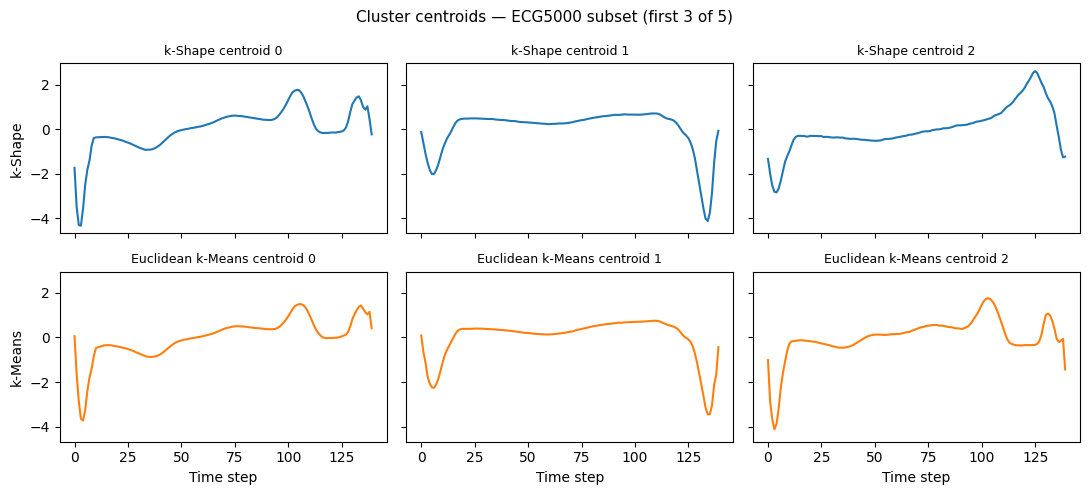

,Algorithm,Distance,k specified?,ARI (vs true labels),Notes
0,k-Shape,SBD (shape-based),Yes (5),0.4819,Handles misaligned series; book's primary method
1,TimeSeriesKMeans,Euclidean,Yes (5),0.4094,Fast baseline; sensitive to time shifts
2,HDBSCAN,Euclidean (flattened),No,0.7805,Found 2 clusters; 67 noise points


In [5]:
# Plot centroids: k-Shape vs Euclidean k-Means (side by side for cluster 0–2)
fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharex=True, sharey=True)

for j in range(3):

    axes[0, j].plot(kshape_ecg.cluster_centers_[j].ravel(), color="C0")

    axes[0, j].set_title(f"k-Shape centroid {j}", fontsize=9)

    axes[1, j].plot(km_ecg.cluster_centers_[j].ravel(), color="C1")

    axes[1, j].set_title(f"Euclidean k-Means centroid {j}", fontsize=9)

axes[0, 0].set_ylabel("k-Shape")

axes[1, 0].set_ylabel("k-Means")

for ax in axes[1, :]:

    ax.set_xlabel("Time step")

plt.suptitle("Cluster centroids — ECG5000 subset (first 3 of 5)", fontsize=11)

plt.tight_layout()

plt.show()

# Summary comparison table
comparison = pd.DataFrame([
    {
        "Algorithm": "k-Shape",
        "Distance": "SBD (shape-based)",
        "k specified?": "Yes (5)",
        "ARI (vs true labels)": round(ari_kshape, 4),
        "Notes": "Handles misaligned series; book's primary method",
    },
    {
        "Algorithm": "TimeSeriesKMeans",
        "Distance": "Euclidean",
        "k specified?": "Yes (5)",
        "ARI (vs true labels)": round(ari_km, 4),
        "Notes": "Fast baseline; sensitive to time shifts",
    },
    {
        "Algorithm": "HDBSCAN",
        "Distance": "Euclidean (flattened)",
        "k specified?": "No",
        "ARI (vs true labels)": round(ari_hdb, 4),
        "Notes": f"Found {n_hdb_clusters} clusters; {n_noise} noise points",
    },
])

display(comparison)


---

## 5. Glossary — All Chapter 13 Terms

| Term | One-line definition |
|------|---------------------|
| **Time series** | Ordered sequence of values indexed by time |
| **ECG (Electrocardiogram)** | Recording of heart electrical activity over time |
| **UCR Time Series Archive** | Benchmark repository of labeled time series datasets |
| **k-Shape** | Clustering algorithm using shape-based distance for series |
| **SBD (Shape-Based Distance)** | Distance invariant to scaling and shifting |
| **TimeSeriesKMeans** | tslearn k-Means with configurable time series metric |
| **Euclidean distance** | Straight-line distance — treats each time index as a dimension |
| **Centroid** | Representative series at cluster center |
| **HDBSCAN** | Hierarchical density clustering without fixed k |
| **ARI (Adjusted Rand Index)** | Cluster-label agreement score (-1 to 1, higher is better) |
| **Noise point** | Outlier not assigned to any HDBSCAN cluster (label -1) |


---

## 6. Chapter 13 Summary

```
Time Series Clustering (Chapter 13) — ECG datasets
├── Load ECGFiveDays + ECG5000 via tslearn UCR loader
├── Scale series with TimeSeriesScalerMeanVariance
├── k-Shape on ECGFiveDays — shape centroids + sample plots
├── ECG5000 subset: k-Shape vs Euclidean k-Means vs HDBSCAN
└── Compare with ARI table and centroid visualizations

Shape-based distances outperform Euclidean when series are misaligned
```

### What's next?

**Chapter 14** concludes the course — recap Parts I–IV, tools comparison, and reflection questions.

---

### Practice questions

1. Why is Euclidean distance a poor default for ECG clustering?
2. What advantage does k-Shape have over standard k-Means for heartbeats?
3. Why did we flatten series for HDBSCAN — what is lost?
4. When would HDBSCAN be preferred over k-Shape?
5. What does an ARI of 0.0 imply about clustering quality vs random labels?
6. How would you choose k if true ECG classes were unknown?
